<a href="https://colab.research.google.com/github/NamithaRStat/Casestudy_18_6_2026/blob/main/Case_Study_supervised_learning_Namitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importing minmaxscaler
from sklearn.preprocessing import MinMaxScaler

# importing onehot encoder
from sklearn.preprocessing import OneHotEncoder

# importing train_test_split function
from sklearn.model_selection import train_test_split

# supervised regression models
# for linear regression
from sklearn.linear_model import LinearRegression
# for kNN regression
from sklearn.neighbors import KNeighborsRegressor
# for sv regression
from sklearn.svm import SVR
#DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
# for RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor


# Matrices for evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Reading data

In [9]:
# mounting drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# calling filepath
filepath = '/content/drive/MyDrive/ICT_AIML/data/House_Pricing.csv'

housing_price = pd.read_csv(filepath)
housing_price.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# EDA

In [11]:
# Choosing Sale Price as target column. other columns as feature columns

In [12]:
# checking number of rows and columns
housing_price.shape

(21613, 21)

In [13]:
# calling details of variables
housing_price.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [14]:
# getting summary of numerical variables
housing_price.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [15]:
# checking unique values for all columns
for i in housing_price.columns :
  print(housing_price[i].unique())

[7129300520 6414100192 5631500400 ... 1523300141  291310100 1523300157]
['14 October 2017' '14 December 2017' '15 February 2016' '14 May 2017'
 '14 June 2017' '15 January 2016' '15 April 2016' '15 March 2016'
 '14 July 2017' '14 August 2017' '14 November 2017' '14 September 2017'
 '15 May 2016']
[221900. 538000. 180000. ... 541800. 610685. 402101.]
[ 3  2  4  5  1  6  7  0  8  9 11 10 33]
[1.   2.25 3.   2.   4.5  1.5  2.5  1.75 2.75 3.25 4.   3.5  0.75 4.75
 5.    nan 4.25 3.75 0.   1.25 5.25 6.   0.5  5.5  6.75 5.75 8.   7.5
 7.75 6.25 6.5 ]
[1180. 2570.  770. ... 3087. 3118. 1425.]
[ 5650.  7242. 10000. ...  5813.  2388.  1076.]
[1.  2.  1.5 3.  2.5 3.5]
['No' 'Yes']
[nan 'Thrice' 'Four' 'Twice' 'Once']
['Fair' 'Excellent' 'Good' 'Bad' 'Okay']
[ 7  6  8 10  9  5  4  3  2  1]
[1180. 2170.  770. 1050. 1680. 3890. 1715. 1060. 1890. 1860.  860. 1430.
 1370. 1810. 1980. 1600. 1200. 1250. 2330. 2270. 1070. 2450. 1710. 1750.
 1400.  790. 2570. 2320. 1190. 1510. 1090. 1280.  930. 2360.  890

In [16]:
# checking value_counts for all columns
for i in housing_price.columns :
  print(housing_price[i].value_counts())

ID
795000620     3
7520000695    2
7200179       2
3904100089    2
6308000010    2
             ..
5602000275    1
1786200010    1
1525079069    1
126049167     1
1211000185    1
Name: count, Length: 21436, dtype: int64
Date House was Sold
15 April 2016        2231
14 July 2017         2211
14 June 2017         2180
14 August 2017       1940
14 October 2017      1878
15 March 2016        1875
14 September 2017    1774
14 May 2017          1768
14 December 2017     1471
14 November 2017     1411
15 February 2016     1250
15 January 2016       978
15 May 2016           646
Name: count, dtype: int64
Sale Price
350000.0    172
450000.0    171
550000.0    159
500000.0    152
425000.0    150
           ... 
357186.0      1
747450.0      1
589999.0      1
402723.0      1
999999.0      1
Name: count, Length: 3625, dtype: int64
No of Bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      199
7       38
0       13
8       13
9        6
10       3
11       1
33       1
Name: count

In [17]:
# Choosing Sale Price as target column.

# Preprocessing

## Checking for duplicates

In [18]:
housing_price.duplicated().sum()

# no duplicated rows

np.int64(0)

## Missing Value Analysis

In [19]:
housing_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [20]:
## removing the column 'No of Times Visited' as 90% of the data is missing.
housing_price.drop(['No of Times Visited'],axis=1, inplace = True)

In [21]:
# droping the rows that have missing values. There is only one missing entry in this columns. So that row removed.
# removing the rows of 'Sale Price' with na as that is the target column.( number of na's  = 4)
housing_price.dropna(subset = ['Zipcode','Latitude','Longitude','Living Area after Renovation (in Sqft)','Sale Price'], inplace = True)



In [22]:
# checking the updated missing value summary
housing_price.isna().sum()


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0


Text(0.5, 1.0, 'Histogram of Flat Area (in Sqft)')

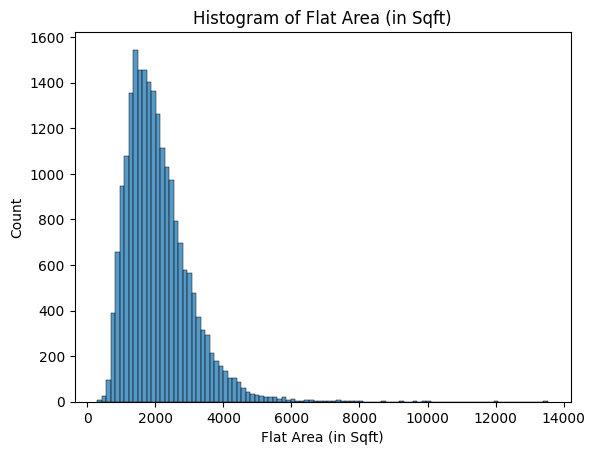

In [23]:
sns.histplot(housing_price['Flat Area (in Sqft)'],bins =100)
plt.title("Histogram of Flat Area (in Sqft)")

Observations from histogram of 'Flat Area (in Sqft)'


*   List item The distribution of flat area is right skewed with more smaller values
*   List item There are two outliers between 11000- 14000?



Text(0.5, 1.0, 'Histogram of number of bathrooms')

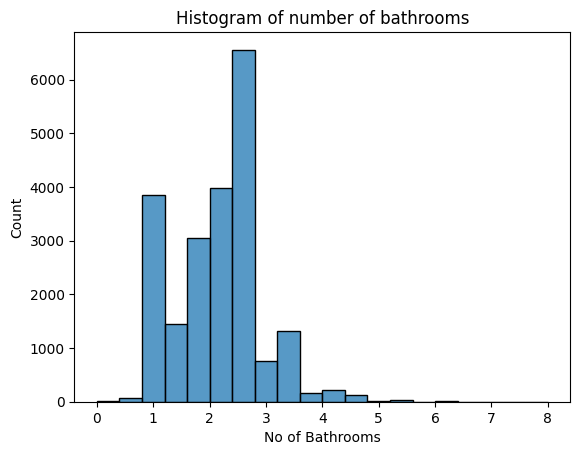

In [24]:
sns.histplot(housing_price['No of Bathrooms'],bins =20)
plt.title("Histogram of number of bathrooms")

Inferences from histogram of 'number of bathrooms'


*   List item The distribution of number of bathrooms is right skewed.

Text(0.5, 1.0, 'Histogram of Lot Area (in Sqft)')

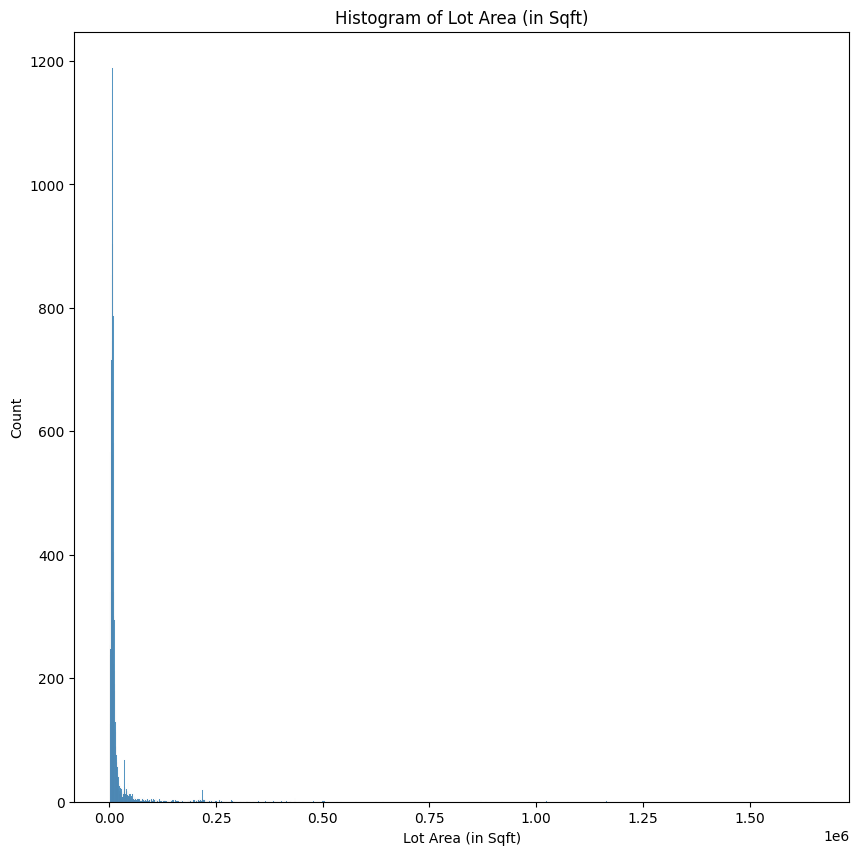

In [25]:
plt.figure(figsize =(10,10))
sns.histplot(housing_price['Lot Area (in Sqft)'])
plt.title("Histogram of Lot Area (in Sqft)")

Inferences from histogram of lot area


*   List item The distribution of lot area is right skewed.
*   List item Suspecting outliers around 0.5

Text(0.5, 1.0, 'Histogram of Area of the House from Basement(in Sqft)')

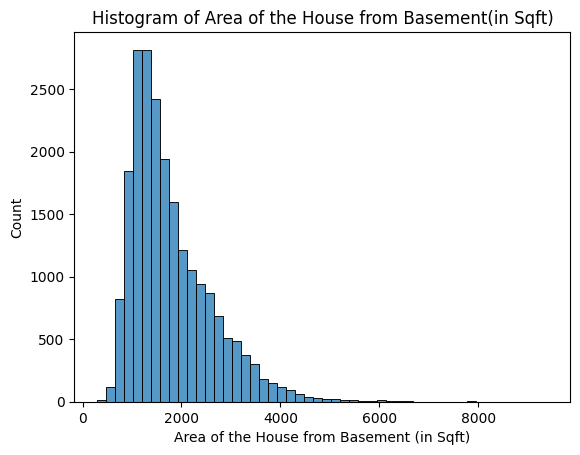

In [26]:
sns.histplot(housing_price['Area of the House from Basement (in Sqft)'],bins = 50)
plt.title("Histogram of Area of the House from Basement(in Sqft)")

Inferences from histogram of Area of the House from Basement


*   The distribution of Area of the House from Basement(in Sqft) is right skewed.
*   Suspecting outliers around 8000

As all columns with missing distributions are skewed to the right, proceeding with calculation of median for replacement.

In [27]:
housing_price['Flat Area (in Sqft)'].fillna(housing_price['Flat Area (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_975/786315807.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_price['Flat Area (in Sqft)'].fillna(housing_price['Flat Area (in Sqft)'].median(),inplace = True)


In [28]:
housing_price['Flat Area (in Sqft)'].fillna(housing_price['Flat Area (in Sqft)'].median(),inplace = True)

housing_price['No of Bathrooms'].fillna(housing_price['No of Bathrooms'].median(),inplace = True)

housing_price['Lot Area (in Sqft)'].fillna(housing_price['Lot Area (in Sqft)'].median(),inplace = True)

housing_price['Area of the House from Basement (in Sqft)'].fillna(housing_price['Area of the House from Basement (in Sqft)'].median(),inplace = True)

/tmp/ipykernel_975/4100491377.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_price['Flat Area (in Sqft)'].fillna(housing_price['Flat Area (in Sqft)'].median(),inplace = True)
/tmp/ipykernel_975/4100491377.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [29]:
#housing_price['No of Bathrooms'] = housing_price['No of Bathrooms'].astype(int)

In [30]:
housing_price.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0


## Outlier Management

In [31]:
# selecting numericl columns
num_col = housing_price.select_dtypes(include=['int64', 'float64'])
num_col

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,538000.0,3,2.25,2570.0,7242.0,2.0,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,360000.0,3,2.50,1530.0,1131.0,3.0,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,400000.0,4,2.50,2310.0,5813.0,2.0,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,402101.0,2,0.75,1020.0,1350.0,2.0,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,400000.0,3,2.50,1600.0,2388.0,2.0,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [32]:
# selecting cat
cat_col = housing_price.select_dtypes(include = ['object','bool'])

In [33]:
# removing column id for 4x4 subplot format

num_col.drop(columns=['ID'], axis=1,inplace = True)


In [34]:
num_col.shape

(21605, 16)

In [35]:
print(num_col)

       Sale Price  No of Bedrooms  No of Bathrooms  Flat Area (in Sqft)  \
0        221900.0               3             1.00               1180.0   
1        538000.0               3             2.25               2570.0   
2        180000.0               2             1.00                770.0   
3        604000.0               4             3.00               1960.0   
4        510000.0               3             2.00               1680.0   
...           ...             ...              ...                  ...   
21608    360000.0               3             2.50               1530.0   
21609    400000.0               4             2.50               2310.0   
21610    402101.0               2             0.75               1020.0   
21611    400000.0               3             2.50               1600.0   
21612    325000.0               2             0.75               1020.0   

       Lot Area (in Sqft)  No of Floors  Overall Grade  \
0                  5650.0           1.0  

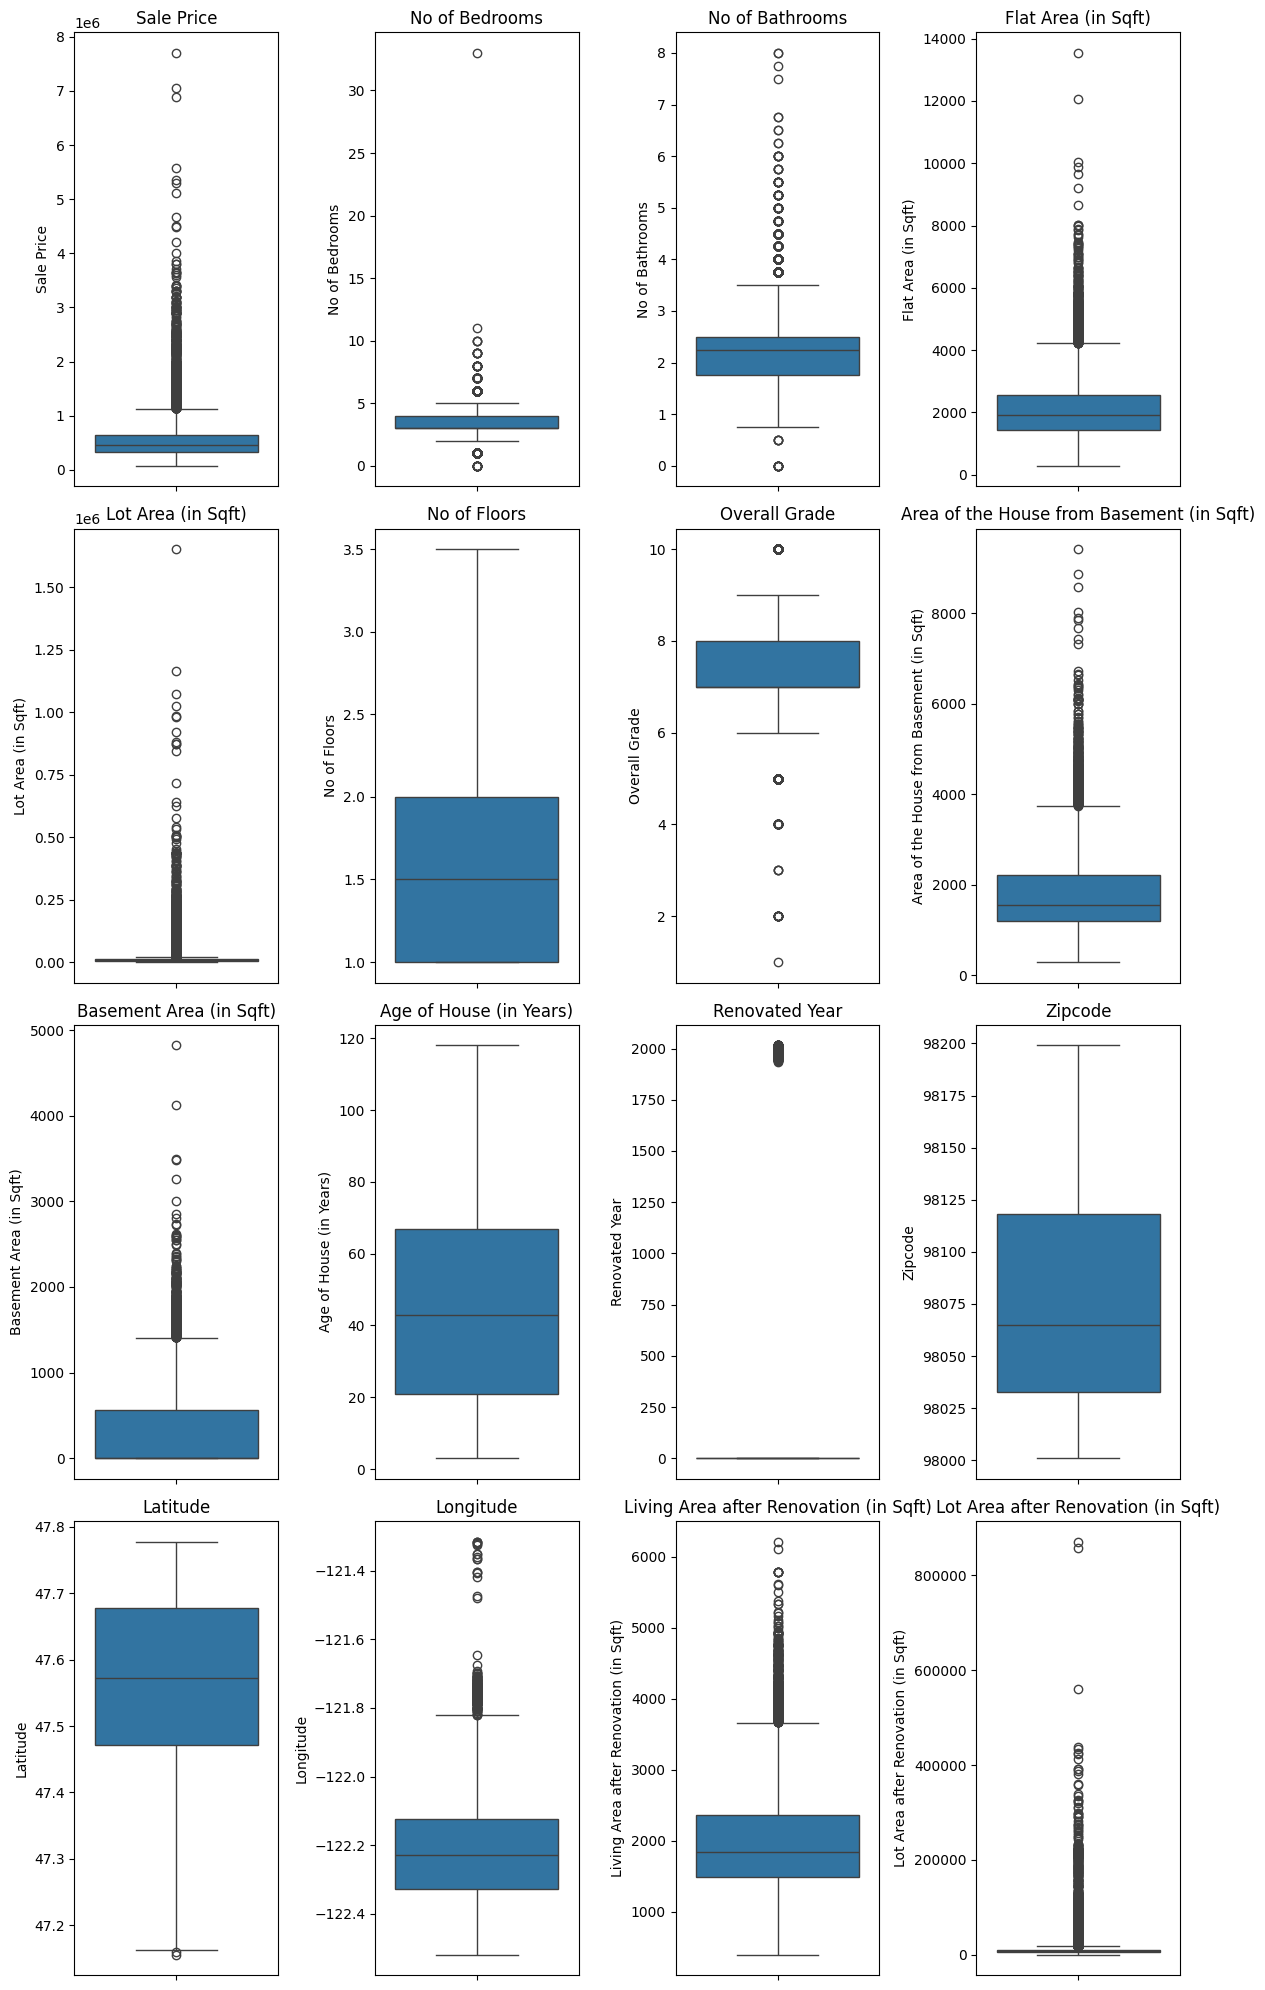

In [36]:

plt.figure(figsize=(12,20))

i= 1
for column in num_col :
  plt.subplot(4,4,i)
  sns.boxplot(num_col[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()



In [37]:
num_col.describe()
# checking the descriptive statistics of num_col


,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.160500e+04,21605.000000,21605.000000,21605.000000,2.160500e+04,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000
mean,5.402050e+05,3.370840,2.114696,2079.941032,1.510820e+04,1.494237,7.623513,1788.388243,291.513307,46.994214,84.340338,98077.939088,47.560033,-122.213876,1986.590558,12771.120065
std,3.674205e+05,0.929939,0.770110,918.393347,4.142714e+04,0.539927,1.105600,827.997287,442.589231,29.367378,401.536399,53.508573,0.138561,0.140831,685.475040,27308.853462
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.215000e+05,3.000000,1.750000,1430.000000,5.042000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470900,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10086.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


<Axes: ylabel='No of Bedrooms'>

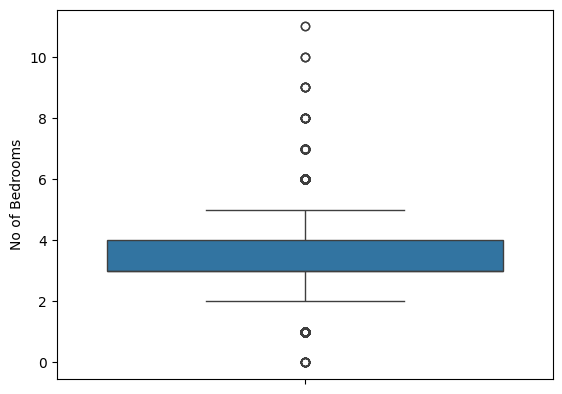

In [38]:
# Number of bedrooms- 33 is a outlier in the case of number of bedroom as it is a extreme value from the rest of the values. Hence clipping that to second largest number of bedrooms

second_largest  = housing_price['No of Bedrooms'].nlargest(2).iloc[-1] # calculating second largesg value
housing_price['No of Bedrooms'] = housing_price['No of Bedrooms'].clip(upper = second_largest) # clipping by second largest value
sns.boxplot(housing_price['No of Bedrooms'])

<Axes: ylabel='Flat Area (in Sqft)'>

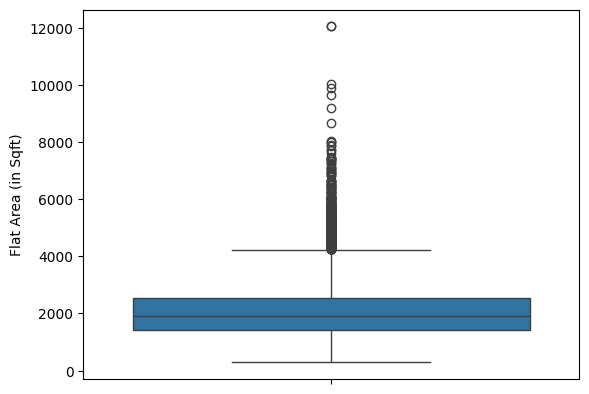

In [39]:
#In Flat Area (in Sqft), there is only two columns which are outliers. Hence clipping the two highest observations to 3rd lrgest observation

third_large_flat  = housing_price['Flat Area (in Sqft)'].nlargest(3).iloc[-2] # calculating third largest value of Flat Area (in Sqft)
housing_price['Flat Area (in Sqft)'] = housing_price['Flat Area (in Sqft)'].clip(upper = third_large_flat) # clipping by third largest value
sns.boxplot(housing_price['Flat Area (in Sqft)'])

In other features, the variables are having right skewed distribution, hence the extreme positive values are indicating propoerties of the variable. Hence they are not removed.

# Scaling

In [40]:
num_col['Renovated Year'].value_counts()

,count
Renovated Year,
0,20692
2014,91
2013,36
2003,36
2005,35
...,...
1948,1
1951,1
1959,1


# Scaling

In [41]:
num_col.columns #checking col names of num_col
num_col = num_col.drop(['Sale Price'], axis=1)

In [42]:
num_col = num_col.drop(['Renovated Year','Overall Grade'], axis=1) # removing 'Renovated Year' as it is categorical

num_col2 = num_col.drop(['Zipcode', 'Latitude', 'Longitude'], axis=1) # this columns are not suitable for scaling, as these are identifiers
                 #<-The numerical columns
num_col2.shape

(21605, 10)

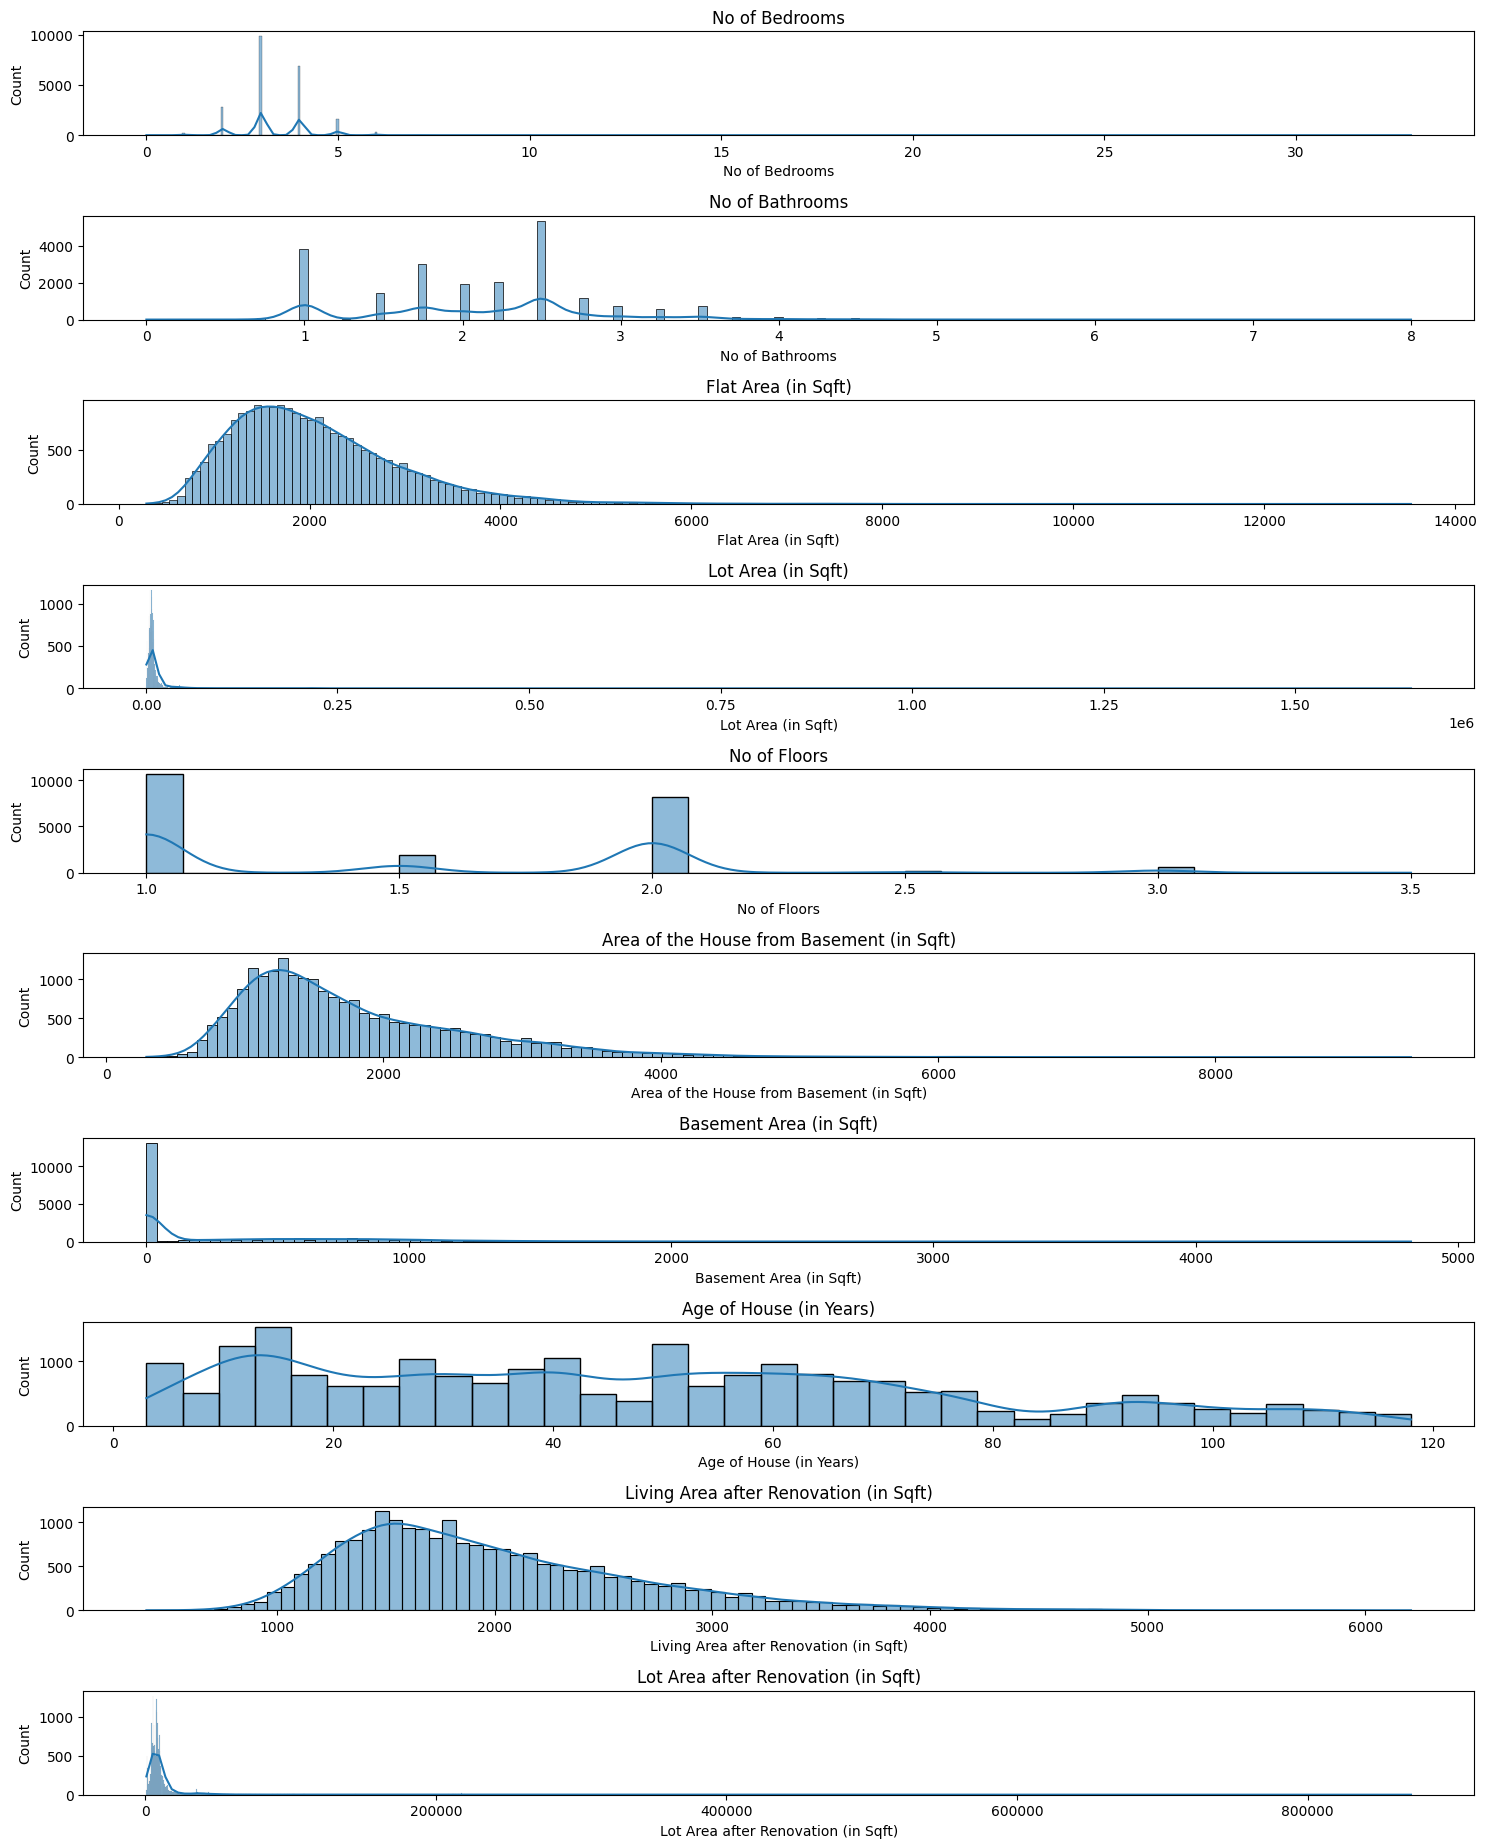

In [43]:
plt.figure(figsize=(15,20))

i= 1
for column in num_col2 :
  plt.subplot(11,1,i)
  sns.histplot(num_col2[column],kde = True)
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

All columns are right skewed, hence applying minmax scaler for all numerical columns.

In [44]:
minmaxscaler = MinMaxScaler() # creating an object

housing_price[num_col.columns] = minmaxscaler.fit_transform(housing_price[num_col.columns]) # transforming numerical columns

# Encoding

In [46]:
#cat_col = housing_price.drop(columns = num_col.columns) # taking all columns which are not numerical
cat_col = cat_col.drop(['Date House was Sold'],axis =1) # dropping the column of ID as it is an identifier and 'Date House was Sold' as it doesnt need encoding


In [47]:
cat_col.columns # checking the names of categorical columns

# all columns are non- binary. Hnece proceeding with one hot encoding

Index(['Waterfront View', 'Condition of the House'], dtype='object')

In [48]:
housing_price = pd.get_dummies(housing_price, columns = cat_col.columns ,dtype = int)
housing_price

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),...,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Waterfront View_No,Waterfront View_Yes,Condition of the House_Bad,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,14 October 2017,221900.0,0.272727,0.12500,0.075680,0.003108,0.0,7,0.097588,...,0.217608,0.161934,0.005742,1,0,0,0,1,0,0
1,6414100192,14 December 2017,538000.0,0.272727,0.28125,0.193878,0.004072,0.4,7,0.206140,...,0.166113,0.222165,0.008027,1,0,0,0,1,0,0
2,5631500400,15 February 2016,180000.0,0.181818,0.12500,0.040816,0.005743,0.0,6,0.052632,...,0.237542,0.399415,0.008513,1,0,0,0,1,0,0
3,2487200875,14 December 2017,604000.0,0.363636,0.37500,0.142007,0.002714,0.0,7,0.083333,...,0.104651,0.165376,0.004996,1,0,0,1,0,0,0
4,1954400510,15 February 2016,510000.0,0.272727,0.25000,0.118197,0.004579,0.0,8,0.152412,...,0.393688,0.241094,0.007871,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,0.272727,0.31250,0.105442,0.000370,0.8,8,0.135965,...,0.143688,0.194631,0.000986,1,0,0,0,1,0,0
21609,6600060120,15 February 2016,400000.0,0.363636,0.31250,0.171769,0.003206,0.4,8,0.221491,...,0.130399,0.246257,0.007523,1,0,0,0,1,0,0
21610,1523300141,14 June 2017,402101.0,0.181818,0.09375,0.062075,0.000503,0.4,7,0.080044,...,0.182724,0.106866,0.001558,1,0,0,0,1,0,0
21611,291310100,15 January 2016,400000.0,0.272727,0.31250,0.111395,0.001132,0.4,8,0.143640,...,0.373754,0.173980,0.000731,1,0,0,0,1,0,0


In [56]:
# droping ID,  Date House was Sold
housing_price.drop(columns = ['ID',  'Date House was Sold'],inplace = True)

In [57]:
housing_price.info()
# ensured all columns are numerical

<class 'pandas.core.frame.DataFrame'>
Index: 21605 entries, 0 to 21612
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Sale Price                                 21605 non-null  float64
 1   No of Bedrooms                             21605 non-null  float64
 2   No of Bathrooms                            21605 non-null  float64
 3   Flat Area (in Sqft)                        21605 non-null  float64
 4   Lot Area (in Sqft)                         21605 non-null  float64
 5   No of Floors                               21605 non-null  float64
 6   Overall Grade                              21605 non-null  int64  
 7   Area of the House from Basement (in Sqft)  21605 non-null  float64
 8   Basement Area (in Sqft)                    21605 non-null  float64
 9   Age of House (in Years)                    21605 non-null  float64
 10  Renovated Year             

# Train-Test Split

In [62]:
#housing_price.columns.tolist()
y = housing_price['Sale Price'] # defining target column
X = housing_price.drop(columns = ['Sale Price']) # defining deture columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Modeling

## Linear Regression

In [71]:
# creating  model obj
linreg = LinearRegression()
# training model
linreg.fit(X_train,y_train)
# creating predictions
y_pred_lin = linreg.predict(X_test)

r2_lin= r2_score(y_test, y_pred_lin) # calculating R_2
mse_lin = mean_squared_error(y_test, y_pred_lin) # Calculating mse
rmse_lin = mean_squared_error(y_test, y_pred_lin) #  root mean square
mae_lin = mean_absolute_error(y_test, y_pred_lin) # mean absolute error

print("R² Score from KNN regression:", r2_lin)
print("MSE from KNN regression:", mse_lin)
print("RMSE from KNN regression:", rmse_lin)
print("MAE from KNN regression:", mae_lin)

R² Score from KNN regression: 0.6551781381163957
MSE from KNN regression: 50313347867.53263
RMSE from KNN regression: 50313347867.53263
MAE from KNN regression: 132015.30999610145


## KNN

In [64]:
# creating  model obj with 4 group of neighbours
knn = KNeighborsRegressor(n_neighbors= 4)
# training model
knn.fit(X_train,y_train)
# creating predictions
y_pred_knn = knn.predict(X_test)


# Evaluation metrices
r2_knn= r2_score(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)

print("R² Score from KNN regression:", r2_knn)
print("MSE from KNN regression:", mse_knn)
print("RMSE from KNN regression:", rmse_knn)
print("MAE from KNN regression:", mae_knn)


R² Score from KNN regression: 0.746200351147382
MSE from KNN regression: 37032193816.32417
RMSE from KNN regression: 37032193816.32417
MAE from KNN regression: 94151.77655635269


## Support Vector Regression

In [66]:
# creating  model obj
svr = SVR()
# training model
svr.fit(X_train,y_train)
# creating predictions
y_pred_svr = svr.predict(X_test)

# Evaluation metrices
r2_svr= r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("R² Score from sv regression:", r2_svr)
print("MSE from sv regression:", mse_svr)
print("RMSE from sv regression:", rmse_svr)
print("MAE from sv regression:", mae_svr)

R² Score from sv regression: -0.06097577881173977
MSE from sv regression: 154808175870.2423
RMSE from sv regression: 154808175870.2423
MAE from sv regression: 225462.1313179501


## Decision tree regression

In [68]:
# creating  model obj
tree = DecisionTreeRegressor()
# training model
tree.fit(X_train,y_train)
# creating predictions
y_pred_tree = tree.predict(X_test)

# Evaluation metrices
r2_tree= r2_score(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = mean_squared_error(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)

print("R² Score from Decision Tree regression:", r2_tree)
print("MSE from Decision Tree regression:", mse_tree)
print("RMSE from Decision Tree regression:", rmse_tree)
print("MAE from Decision Tree regression:", mae_tree)

R² Score from Decision Tree regression: 0.7457769325189048
MSE from Decision Tree regression: 37093975307.29981
RMSE from Decision Tree regression: 37093975307.29981
MAE from Decision Tree regression: 100445.17079379773


## Random Forest Regression

In [69]:
# creating  model obj
forest = RandomForestRegressor()
forest.fit(X_train,y_train)
y_pred_forest = forest.predict(X_test)

# Evaluation metrices
r2_forest= r2_score(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = mean_squared_error(y_test, y_pred_forest)
mae_forest = mean_absolute_error(y_test, y_pred_forest)

print("R² Score from Random Forest Regression:", r2_forest)
print("MSE from Random Forest Regression:", mse_forest)
print("RMSE from Random Forest Regression:", rmse_forest)
print("MAE from Random Forest Regression:", mae_forest)

R² Score from Random Forest Regression: 0.8752343231961246
MSE from Random Forest Regression: 18204701014.811176
RMSE from Random Forest Regression: 18204701014.811176
MAE from Random Forest Regression: 70885.01939393806


# Conclusion

The best regression model is decision tree with R_2 core 0.875 which indicates that 87.5 % of the variation in the selling price is explained by the decision tree model created.

##